# 04 — Modeling & MLflow Tracking

> **Hurdle Model (Two-Stage Prediction)**
>
> - **Stage 1 (Classification)**: Predict `P(sold_to_third_party)` for all offered lots
> - **Stage 2 (Regression)**: Predict `log_price_detrended` (`log_price_gns − log_year_median_price_prior`)
> - **Combined**: `E[price] = P(sold) × exp(pred_detrended + log_year_median + σ²/2)`

## Detrending Rationale

Stage 2 target is **detrended**: `log_price_detrended = log_price_gns − log_year_median_price_prior`.
This removes the +78% nominal drift (2009–2025), letting the model focus on relative horse value.
At prediction time, the trend is re-added: `log_price_nominal = pred_detrended + log_year_median_price_prior`.
See §3.2 in `03_FeatureEngineering.ipynb` for details.

---

## Experimental Setup

| Aspect | Setting |
|---|---|
| **Metric** | PR-AUC (dev), AUC-ROC (report) — Stage 1 · RMSE log (opt), MAPE/MdAPE (report) — Stage 2 |
| **Temporal Split** | Train 2009–2019 · Val 2020–2021 · Test 2022–2025 (OOT, touched once) |
| **Reproducibility** | Seed = 42 (PYTHONHASHSEED, numpy, random) |
| **MLflow** | Tracking URI `./mlruns/` — full hyperparameter & metric logging |
| **Optuna** | TPE sampler, TimeSeriesSplit(4) or early-stopping eval set |
| **Pruning** | MedianPruner on XGBoost, LightGBM, CatBoost trials |

## Models Compared

| Stage 1 (Classification) | Stage 2 (Regression) |
|---|---|
| Logistic Regression (baseline) | Ridge Regression (baseline) |
| Random Forest | Random Forest Regressor |
| XGBoost (hist, n_jobs=-1) | XGBoost Regressor |
| LightGBM (n_jobs=-1) | LightGBM Regressor |
| CatBoost (thread_count=-1) | CatBoost Regressor |
| **Stacking** (LR meta) | **Stacking** (Ridge meta) |

In [1]:
import os, sys, warnings, random, json, math

# reproducibility
RANDOM_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
random.seed(RANDOM_SEED)

# core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    f1_score, confusion_matrix, precision_recall_curve, roc_curve,
    mean_squared_error, r2_score, mean_absolute_error
)

# boosting frameworks
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
import xgboost as xgb
import lightgbm as lgb

# optuna + mlflow
import optuna
from optuna.integration.mlflow import MLflowCallback
from optuna.pruners import MedianPruner
from mlflow.tracking import MlflowClient
import mlflow

# project imports
from pathlib import Path
PROJECT_ROOT = Path('').resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
import joblib
from src.model_wrappers import StackingClassifierWrapper, StackingRegressorWrapper
from src.constants import TRAIN_MAX_YEAR, VAL_MIN_YEAR, VAL_MAX_YEAR, TEST_MIN_YEAR



optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_tracking_uri("./mlruns")

# suppress
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print(f"xgboost  : {xgb.__version__}")
print(f"lightgbm : {lgb.__version__}")

xgboost  : 3.2.0
lightgbm : 4.6.0


In [2]:
# ── paths ──
DATA_DIR = "../data/processed"
CLASS_PATH = f"{DATA_DIR}/classification_ready.parquet"
REG_PATH    = f"{DATA_DIR}/regression_ready.parquet"
UNIV_PATH   = f"{DATA_DIR}/inference_universe.parquet"

# ── Derive features from parquet columns ──
# feature_documentation.csv no longer exported; feature lists come from
# the parquet columns minus known metadata column sets.
REG_META = {'sold_to_third_party', 'vendor_buyback', 'sale_year', 'lot_uid',
            'log_price_gns', 'log_year_median_price_prior', 'log_price_detrended'}
CLF_META = {'sale_year', 'sold_to_third_party', 'lot_uid', 'vendor_buyback', 'lot_not_sold'}


import pyarrow.parquet as pq
clf_cols = pq.read_schema(CLASS_PATH).names
reg_cols = pq.read_schema(REG_PATH).names

features_clf = [c for c in clf_cols if c not in CLF_META]
features_reg = [c for c in reg_cols if c not in REG_META]

print(f"features_clf: {len(features_clf)}")
print(f"features_reg: {len(features_reg)}")

# ── MLflow experiments ──
MLFLOW_EXP_CLF = "stage1_classification"
MLFLOW_EXP_REG = "stage2_regression"

features_clf: 20
features_reg: 12


In [3]:
# Load datasets
clf_df = pd.read_parquet(CLASS_PATH)
reg_df = pd.read_parquet(REG_PATH)
univ_df = pd.read_parquet(UNIV_PATH)

print("classification_ready:", clf_df.shape)
print("regression_ready   :", reg_df.shape)
print("inference_universe :", univ_df.shape)
print("Year ranges:", clf_df['sale_year'].min(), "-", clf_df['sale_year'].max())

classification_ready: (18966, 25)
regression_ready   : (16508, 19)
inference_universe : (18966, 32)
Year ranges: 2009 - 2025


In [4]:
# ── Stage 1 splits ──
clf_train = clf_df[clf_df['sale_year'] <= TRAIN_MAX_YEAR].copy()
clf_val   = clf_df[(clf_df['sale_year'] >= VAL_MIN_YEAR) & (clf_df['sale_year'] <= VAL_MAX_YEAR)].copy()
clf_test  = clf_df[clf_df['sale_year'] >= TEST_MIN_YEAR].copy()

# ── Stage 2 splits ──
reg_train = reg_df[reg_df['sale_year'] <= TRAIN_MAX_YEAR].copy()
reg_val   = reg_df[(reg_df['sale_year'] >= VAL_MIN_YEAR) & (reg_df['sale_year'] <= VAL_MAX_YEAR)].copy()
reg_test  = reg_df[reg_df['sale_year'] >= TEST_MIN_YEAR].copy()

print("=== Stage 1 ===")
print(f"Train: {clf_train.shape[0]} rows ({clf_train['sale_year'].min()}-{clf_train['sale_year'].max()})")
print(f"Val  : {clf_val.shape[0]} rows ({clf_val['sale_year'].min()}-{clf_val['sale_year'].max()})")
print(f"Test : {clf_test.shape[0]} rows ({clf_test['sale_year'].min()}-{clf_test['sale_year'].max()})")
print("\n=== Stage 2 ===")
print(f"Train: {reg_train.shape[0]} rows ({reg_train['sale_year'].min()}-{reg_train['sale_year'].max()})")
print(f"Val  : {reg_val.shape[0]} rows ({reg_val['sale_year'].min()}-{reg_val['sale_year'].max()})")
print(f"Test : {reg_test.shape[0]} rows ({reg_test['sale_year'].min()}-{reg_test['sale_year'].max()})")
print("Sold ratio (reg_train):", reg_train['sold_to_third_party'].mean().round(3))
print("Sold ratio (reg_val)  :", reg_val['sold_to_third_party'].mean().round(3))
print("Sold ratio (reg_test) :", reg_test['sold_to_third_party'].mean().round(3))
print("\n\nSold ratio (clf_train):", clf_train['sold_to_third_party'].mean().round(3))
print("Sold ratio (clf_val)  :", clf_val['sold_to_third_party'].mean().round(3))
print("Sold ratio (clf_test) :", clf_test['sold_to_third_party'].mean().round(3))
# Ensure chronologically sorted for TimeSeriesSplit later
sort_cols = ['sale_year']
if 'lot' in clf_train.columns:
    sort_cols.append('lot')
clf_train = clf_train.sort_values(by=sort_cols)
reg_train = reg_train.sort_values(by=sort_cols)

=== Stage 1 ===
Train: 12097 rows (2009-2019)
Val  : 2198 rows (2020-2021)
Test : 4671 rows (2022-2025)

=== Stage 2 ===
Train: 10424 rows (2009-2019)
Val  : 1971 rows (2020-2021)
Test : 4113 rows (2022-2025)
Sold ratio (reg_train): 1.0
Sold ratio (reg_val)  : 1.0
Sold ratio (reg_test) : 1.0


Sold ratio (clf_train): 0.862
Sold ratio (clf_val)  : 0.897
Sold ratio (clf_test) : 0.881


## Stage 1 — Classification: P(sold_to_third_party)

### Strategy

Six models are trained and compared:

1. **Logistic Regression** — calibrated baseline (balanced weights, saga solver)
2. **Random Forest** — 25 Optuna trials, 4-fold temporal CV on PR-AUC, parallel via `n_jobs=-1`
3. **XGBoost** — 50 Optuna trials, hist tree method, early stopping + MedianPruner, class weight via `scale_pos_weight`
4. **LightGBM** — 50 Optuna trials, native PR-AUC eval metric, early stopping + MedianPruner
5. **CatBoost** — 30 Optuna trials, auto-class-weights, temporal 80/20 eval for early stopping + MedianPruner
6. **Stacking Classifier** — val-based meta-learner (Logistic Regression) over the four tree-model predictions; avoids OOF to preserve temporal integrity

In [5]:
mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_CLF)

X_train = clf_train[features_clf]
X_val   = clf_val[features_clf]
X_test  = clf_test[features_clf]
y_train = clf_train['sold_to_third_party']
y_val   = clf_val['sold_to_third_party']
y_test  = clf_test['sold_to_third_party']

with mlflow.start_run(run_name="baseline_logistic_regression"):
    # saga converges faster than lbfgs on large datasets with many features
    lr = LogisticRegression(class_weight='balanced', max_iter=5000,
                             solver='saga', random_state=RANDOM_SEED, C=1.0)
    lr.fit(X_train, y_train)

    prob_val  = lr.predict_proba(X_val)[:, 1]
    prob_test = lr.predict_proba(X_test)[:, 1]

    roc_val   = roc_auc_score(y_val, prob_val)
    pr_val    = average_precision_score(y_val, prob_val)
    brier_val = brier_score_loss(y_val, prob_val)

    mlflow.log_params({"C": 1.0, "solver": "saga", "class_weight": "balanced", "model": "LogisticRegression"})
    mlflow.log_metrics({"val_roc_auc": roc_val, "val_pr_auc": pr_val, "val_brier": brier_val})
    mlflow.sklearn.log_model(lr, "model")

    print(f"LR  | Val  ROC-AUC={roc_val:.4f}  PR-AUC={pr_val:.4f}  Brier={brier_val:.4f}")

2026/06/22 16:58:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 16:58:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/22 16:59:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LR  | Val  ROC-AUC=0.5984  PR-AUC=0.9190  Brier=0.1946


In [6]:
def objective_rf(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 600)
    max_depth = trial.suggest_int("max_depth", 4, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5])

    rf = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth if max_depth < 20 else None,
        min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
        max_features=max_features, class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1,
    )
    tscv = TimeSeriesSplit(n_splits=4)
    scores = cross_val_score(rf, clf_train[features_clf], y_train,
                              cv=tscv, scoring="average_precision", n_jobs=1)
    return scores.mean()

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_CLF)
_exp_id_clf = mlflow.get_experiment_by_name(MLFLOW_EXP_CLF).experiment_id
mlf_cb = MLflowCallback(
    metric_name="val_pr_auc",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_clf}
)

with mlflow.start_run(run_name="random_forest_optuna") as run:
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective_rf, n_trials=25, callbacks=[mlf_cb])

    best = study.best_params
    mlflow.log_params({"model": "RandomForest", **best})
    print("Best RF params:", best)

    rf_best = RandomForestClassifier(
        n_estimators=best["n_estimators"],
        max_depth=best["max_depth"] if best["max_depth"] < 20 else None,
        min_samples_split=best["min_samples_split"],
        min_samples_leaf=best["min_samples_leaf"],
        max_features=best["max_features"],
        class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1,
    )
    rf_best.fit(X_train, y_train)

    prob_val_rf  = rf_best.predict_proba(X_val)[:, 1]
    prob_test_rf = rf_best.predict_proba(X_test)[:, 1]

    roc_val_rf   = roc_auc_score(y_val, prob_val_rf)
    pr_val_rf    = average_precision_score(y_val, prob_val_rf)
    brier_val_rf = brier_score_loss(y_val, prob_val_rf)

    mlflow.log_metrics({"val_roc_auc": roc_val_rf, "val_pr_auc": pr_val_rf, "val_brier": brier_val_rf})
    mlflow.sklearn.log_model(rf_best, "model")

    print(f"RF  | Val  ROC-AUC={roc_val_rf:.4f}  PR-AUC={pr_val_rf:.4f}  Brier={brier_val_rf:.4f}")

2026/06/22 16:59:01 INFO mlflow.tracking.fluent: Experiment with name 'no-name-85ed5a99-23c4-475c-8408-7e2bd4bbb7f5' does not exist. Creating a new experiment.


Best RF params: {'n_estimators': 589, 'max_depth': 6, 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2'}


2026/06/22 16:59:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 16:59:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/22 16:59:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


RF  | Val  ROC-AUC=0.6656  PR-AUC=0.9405  Brier=0.1680


In [7]:
# ── XGBoost (Stage 1) — CPU multi-thread, hist tree method, early stopping ──
_split_idx_clf = int(len(X_train) * 0.8)
_yr_train = clf_train['sale_year']
assert _yr_train.iloc[:_split_idx_clf].max() <= _yr_train.iloc[_split_idx_clf:].min(), \
    "XGBoost split violates temporal order"

X_tr_xgb, X_ev_xgb = X_train.iloc[:_split_idx_clf], X_train.iloc[_split_idx_clf:]
y_tr_xgb, y_ev_xgb = y_train.iloc[:_split_idx_clf], y_train.iloc[_split_idx_clf:]
_scale_pos = (y_tr_xgb == 0).sum() / max((y_tr_xgb == 1).sum(), 1)

def objective_xgb(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.1, 10, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }
    pruning_cb = optuna.integration.XGBoostPruningCallback(trial, "validation_0-aucpr")
    model = xgb.XGBClassifier(
        **params,
        tree_method="hist", device="cpu", n_jobs=-1,
        scale_pos_weight=_scale_pos, eval_metric="aucpr",
        random_state=RANDOM_SEED, early_stopping_rounds=30, verbosity=0,
        callbacks=[pruning_cb],
    )
    model.fit(X_tr_xgb, y_tr_xgb, eval_set=[(X_ev_xgb, y_ev_xgb)], verbose=False)
    prob = model.predict_proba(X_ev_xgb)[:, 1]
    return average_precision_score(y_ev_xgb, prob)

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_CLF)
_exp_id_clf = mlflow.get_experiment_by_name(MLFLOW_EXP_CLF).experiment_id
mlf_cb_xgb = MLflowCallback(
    metric_name="val_pr_auc",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_clf}
)

with mlflow.start_run(run_name="xgboost_optuna") as run:
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    )
    study.optimize(objective_xgb, n_trials=50, callbacks=[mlf_cb_xgb])

    bp_xgb = study.best_params
    mlflow.log_params({"model": "XGBoost", **bp_xgb})
    print("Best XGB params:", bp_xgb)

    xgb_best = xgb.XGBClassifier(
        **bp_xgb,
        tree_method="hist", device="cpu", n_jobs=-1,
        scale_pos_weight=_scale_pos, eval_metric="aucpr",
        random_state=RANDOM_SEED, verbosity=0,
    )
    xgb_best.fit(X_train, y_train, verbose=False)

    prob_val_xgb  = xgb_best.predict_proba(X_val)[:, 1]
    prob_test_xgb = xgb_best.predict_proba(X_test)[:, 1]

    roc_val_xgb   = roc_auc_score(y_val, prob_val_xgb)
    pr_val_xgb    = average_precision_score(y_val, prob_val_xgb)
    brier_val_xgb = brier_score_loss(y_val, prob_val_xgb)

    mlflow.log_metrics({"val_roc_auc": roc_val_xgb, "val_pr_auc": pr_val_xgb, "val_brier": brier_val_xgb})
    mlflow.xgboost.log_model(xgb_best, "model")

    print(f"XGB | Val  ROC-AUC={roc_val_xgb:.4f}  PR-AUC={pr_val_xgb:.4f}  Brier={brier_val_xgb:.4f}")

2026/06/22 16:59:59 INFO mlflow.tracking.fluent: Experiment with name 'no-name-ba9b88e8-5a56-4bbd-98f1-581f179f2b82' does not exist. Creating a new experiment.


Best XGB params: {'n_estimators': 971, 'learning_rate': 0.25210608104317156, 'max_depth': 3, 'reg_lambda': 0.6841479363602019, 'subsample': 0.62845693101656, 'colsample_bytree': 0.655236453483252}


2026/06/22 17:00:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 17:00:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


XGB | Val  ROC-AUC=0.5930  PR-AUC=0.9229  Brier=0.1202


In [8]:
# ── LightGBM (Stage 1) — CPU multi-thread, native PR-AUC eval ──
def objective_lgbm(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 300),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.1, 10, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }
    pruning_cb = optuna.integration.LightGBMPruningCallback(trial, "average_precision")
    model = lgb.LGBMClassifier(
        **params,
        objective="binary", metric="average_precision",
        class_weight="balanced", random_state=RANDOM_SEED,
        n_jobs=-1, subsample_freq=1, verbose=-1,
    )
    model.fit(
        X_tr_xgb, y_tr_xgb,
        eval_set=[(X_ev_xgb, y_ev_xgb)],
        eval_metric="average_precision",
        callbacks=[lgb.early_stopping(30, verbose=False), pruning_cb],
    )
    prob = model.predict_proba(X_ev_xgb)[:, 1]
    return average_precision_score(y_ev_xgb, prob)

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_CLF)
_exp_id_clf = mlflow.get_experiment_by_name(MLFLOW_EXP_CLF).experiment_id
mlf_cb_lgbm = MLflowCallback(
    metric_name="val_pr_auc",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_clf}
)

with mlflow.start_run(run_name="lightgbm_optuna") as run:
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    )
    study.optimize(objective_lgbm, n_trials=50, callbacks=[mlf_cb_lgbm])

    bp_lgbm = study.best_params
    mlflow.log_params({"model": "LightGBM", **bp_lgbm})
    print("Best LGBM params:", bp_lgbm)

    lgbm_best = lgb.LGBMClassifier(
        **bp_lgbm,
        objective="binary", class_weight="balanced",
        random_state=RANDOM_SEED, n_jobs=-1, subsample_freq=1, verbose=-1,
    )
    lgbm_best.fit(X_train, y_train)

    prob_val_lgbm  = lgbm_best.predict_proba(X_val)[:, 1]
    prob_test_lgbm = lgbm_best.predict_proba(X_test)[:, 1]

    roc_val_lgbm   = roc_auc_score(y_val, prob_val_lgbm)
    pr_val_lgbm    = average_precision_score(y_val, prob_val_lgbm)
    brier_val_lgbm = brier_score_loss(y_val, prob_val_lgbm)

    mlflow.log_metrics({"val_roc_auc": roc_val_lgbm, "val_pr_auc": pr_val_lgbm, "val_brier": brier_val_lgbm})
    mlflow.lightgbm.log_model(lgbm_best, "model")

    print(f"LGBM | Val  ROC-AUC={roc_val_lgbm:.4f}  PR-AUC={pr_val_lgbm:.4f}  Brier={brier_val_lgbm:.4f}")

2026/06/22 17:00:14 INFO mlflow.tracking.fluent: Experiment with name 'no-name-f9862935-2fe8-41f7-95df-0ef2e4cef8e3' does not exist. Creating a new experiment.


Best LGBM params: {'n_estimators': 474, 'learning_rate': 0.05585497929982856, 'num_leaves': 21, 'reg_lambda': 0.46721780159934706, 'subsample': 0.8325659954539797, 'colsample_bytree': 0.5019338225591672, 'min_child_samples': 78}


2026/06/22 17:00:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 17:00:52 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/22 17:00:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LGBM | Val  ROC-AUC=0.6494  PR-AUC=0.9338  Brier=0.1200


In [9]:
def objective_cb(trial):
    iterations = trial.suggest_int("iterations", 200, 1000)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    depth = trial.suggest_int("depth", 4, 10)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1, 10, log=True)
    bagging_temp = trial.suggest_float("bagging_temperature", 0.0, 1.0)

    split_idx = int(len(X_train) * 0.8)
    X_tr, X_ev = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
    y_tr, y_ev = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

    train_years = clf_train['sale_year']
    first_half_max = train_years.iloc[:split_idx].max()
    second_half_min = train_years.iloc[split_idx:].min()
    assert first_half_max <= second_half_min, (
        f"CatBoost split violates temporal order: "
        f"first 80% max year={first_half_max}, last 20% min year={second_half_min}"
    )

    cb = CatBoostClassifier(
        iterations=iterations, learning_rate=learning_rate, depth=depth,
        l2_leaf_reg=l2_leaf_reg, bagging_temperature=bagging_temp,
        loss_function="Logloss", eval_metric="AUC",
        random_seed=RANDOM_SEED, verbose=False, thread_count=-1,
        auto_class_weights="Balanced", early_stopping_rounds=50,
    )
    cb.fit(X_tr, y_tr, eval_set=(X_ev, y_ev), use_best_model=True)
    return cb.best_score_['validation']['AUC']

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_CLF)
_exp_id_clf = mlflow.get_experiment_by_name(MLFLOW_EXP_CLF).experiment_id
mlf_cb_clf = MLflowCallback(
    metric_name="val_pr_auc",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_clf}
)

with mlflow.start_run(run_name="catboost_optuna") as run:
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    )
    study.optimize(objective_cb, n_trials=30, callbacks=[mlf_cb_clf])

    best_cb = study.best_params
    mlflow.log_params({"model": "CatBoost", **best_cb})
    print("Best CB params:", best_cb)

    cb_best = CatBoostClassifier(
        iterations=best_cb["iterations"], learning_rate=best_cb["learning_rate"],
        depth=best_cb["depth"], l2_leaf_reg=best_cb["l2_leaf_reg"],
        bagging_temperature=best_cb["bagging_temperature"],
        loss_function="Logloss", eval_metric="AUC",
        random_seed=RANDOM_SEED, verbose=False, thread_count=-1,
        auto_class_weights="Balanced", early_stopping_rounds=50,
    )
    cb_best.fit(X_train, y_train, verbose=False)

    prob_val_cb  = cb_best.predict_proba(X_val)[:, 1]
    prob_test_cb = cb_best.predict_proba(X_test)[:, 1]

    roc_val_cb   = roc_auc_score(y_val, prob_val_cb)
    pr_val_cb    = average_precision_score(y_val, prob_val_cb)
    brier_val_cb = brier_score_loss(y_val, prob_val_cb)

    mlflow.log_metrics({"val_roc_auc": roc_val_cb, "val_pr_auc": pr_val_cb, "val_brier": brier_val_cb})
    mlflow.catboost.log_model(cb_best, "model")

    print(f"CatBoost | Val  ROC-AUC={roc_val_cb:.4f}  PR-AUC={pr_val_cb:.4f}  Brier={brier_val_cb:.4f}")

2026/06/22 17:00:55 INFO mlflow.tracking.fluent: Experiment with name 'no-name-e71b1fc1-3a59-448e-8019-efc7c344fbe7' does not exist. Creating a new experiment.


Best CB params: {'iterations': 690, 'learning_rate': 0.01607123851203988, 'depth': 6, 'l2_leaf_reg': 2.324672848950434, 'bagging_temperature': 0.45606998421703593}


2026/06/22 17:01:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 17:01:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


CatBoost | Val  ROC-AUC=0.6721  PR-AUC=0.9396  Brier=0.1361


In [10]:
# ── Stage 1 Stacking — val-based, temporal-clean ──
# Base models trained on TRAIN; their VAL predictions become meta-features for an LR meta-learner.
# Avoids OOF (which would leak across temporal folds) while still letting the meta-learner
# learn optimal weights between base models.

base_clf_runs = {
    "rf":   prob_val_rf,
    "xgb":  prob_val_xgb,
    "lgbm": prob_val_lgbm,
    "cb":   prob_val_cb,
}
base_clf_test = {
    "rf":   prob_test_rf,
    "xgb":  prob_test_xgb,
    "lgbm": prob_test_lgbm,
    "cb":   prob_test_cb,
}

Z_val_clf  = np.column_stack([base_clf_runs[k]  for k in ["rf", "xgb", "lgbm", "cb"]])
Z_test_clf = np.column_stack([base_clf_test[k] for k in ["rf", "xgb", "lgbm", "cb"]])

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_CLF)
with mlflow.start_run(run_name="stacking_classifier"):
    meta_clf = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)
    meta_clf.fit(Z_val_clf, y_val)

    prob_val_stk  = meta_clf.predict_proba(Z_val_clf)[:, 1]
    prob_test_stk = meta_clf.predict_proba(Z_test_clf)[:, 1]

    roc_val_stk   = roc_auc_score(y_val, prob_val_stk)
    pr_val_stk    = average_precision_score(y_val, prob_val_stk)
    brier_val_stk = brier_score_loss(y_val, prob_val_stk)

    weights = dict(zip(["rf", "xgb", "lgbm", "cb"], meta_clf.coef_[0].round(4)))
    mlflow.log_params({"model": "StackingClassifier", "meta": "LogisticRegression", **{f"w_{k}": v for k, v in weights.items()}})
    mlflow.log_metrics({"val_roc_auc": roc_val_stk, "val_pr_auc": pr_val_stk, "val_brier": brier_val_stk})
    mlflow.sklearn.log_model(meta_clf, "model")

    print(f"Stacking | Val  ROC-AUC={roc_val_stk:.4f}  PR-AUC={pr_val_stk:.4f}  Brier={brier_val_stk:.4f}")
    print(f"Meta-learner weights: {weights}")

2026/06/22 17:01:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 17:01:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/22 17:01:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Stacking | Val  ROC-AUC=0.6736  PR-AUC=0.9406  Brier=0.0876
Meta-learner weights: {'rf': np.float64(0.9262), 'xgb': np.float64(-0.4663), 'lgbm': np.float64(1.2389), 'cb': np.float64(1.8639)}


In [11]:
# Stage 1 comparison — val metrics only (test set touched once in final eval cell)
# IMPORTANT: filter out nested Optuna trial runs — keep only the 6 top-level.
TOP_CLF_RUNS = {
    "baseline_logistic_regression",
    "random_forest_optuna",
    "xgboost_optuna",
    "lightgbm_optuna",
    "catboost_optuna",
    "stacking_classifier",
}

client = MlflowClient()
exp = client.get_experiment_by_name(MLFLOW_EXP_CLF)
all_runs = client.search_runs(exp.experiment_id)
runs = [r for r in all_runs if r.info.run_name in TOP_CLF_RUNS]

data = []
for r in runs:
    p = r.data.params
    m = r.data.metrics
    data.append({
        "run": r.info.run_name,
        "model": p.get("model", "?"),
        "val_roc_auc": round(m.get("val_roc_auc", 0), 4),
        "val_pr_auc":  round(m.get("val_pr_auc", 0), 4),
        "val_brier":   round(m.get("val_brier", float("nan")), 4),
    })

display(pd.DataFrame(data).sort_values("val_pr_auc", ascending=False))

,run,model,val_roc_auc,val_pr_auc,val_brier
31,random_forest_optuna,RandomForest,0.6844,0.9460,0.1781
25,random_forest_optuna,RandomForest,0.6850,0.9457,0.1848
22,random_forest_optuna,RandomForest,0.6850,0.9457,0.1848
18,stacking_classifier,StackingClassifier,0.6820,0.9448,0.0879
27,stacking_classifier,StackingClassifier,0.6811,0.9443,0.0877
28,catboost_optuna,CatBoost,0.6708,0.9415,0.1376
6,stacking_classifier,StackingClassifier,0.6757,0.9411,0.0874
12,stacking_classifier,StackingClassifier,0.6757,0.9411,0.0874
16,random_forest_optuna,RandomForest,0.6673,0.9410,0.1711
10,random_forest_optuna,RandomForest,0.6673,0.9410,0.1711


In [12]:
# Determine best model by val PR-AUC (across all 6), broken by Brier if tied

stacking_clf_wrapper = StackingClassifierWrapper(
    base_models={"rf": rf_best, "xgb": xgb_best, "lgbm": lgbm_best, "cb": cb_best},
    meta=meta_clf,
    base_keys=["rf", "xgb", "lgbm", "cb"],
)

all_clf_candidates = {
    "baseline_logistic_regression": (prob_val,      prob_test,      lr,                   True),
    "random_forest_optuna":         (prob_val_rf,   prob_test_rf,   rf_best,              False),
    "xgboost_optuna":               (prob_val_xgb,  prob_test_xgb,  xgb_best,             False),
    "lightgbm_optuna":              (prob_val_lgbm, prob_test_lgbm, lgbm_best,            False),
    "catboost_optuna":              (prob_val_cb,   prob_test_cb,   cb_best,              False),
    "stacking_classifier":          (prob_val_stk,  prob_test_stk,  stacking_clf_wrapper, True),
}

# ── Multi-criterion selection: PR-AUC primary, Brier tiebreaker if top-2 within <= 0.001 ──
_pr_auc_in_memory = {name: average_precision_score(y_val, vals[0]) for name, vals in all_clf_candidates.items()}
_sorted = sorted(_pr_auc_in_memory.items(), key=lambda x: -x[1])

if len(_sorted) >= 2 and (_sorted[0][1] - _sorted[1][1]) <= 0.001:
    _brier_in_memory = {
        name: brier_score_loss(y_val, all_clf_candidates[name][0])
        for name, _ in _sorted[:2]
    }
    best_run_name = min(_brier_in_memory, key=_brier_in_memory.get)
    print(f"PR-AUC tie (diff <= 0.001) → broken by Brier: {best_run_name} "
          f"(Brier={_brier_in_memory[best_run_name]:.4f})")
else:
    best_run_name = _sorted[0][0]
    print("Best Stage 1 model:", best_run_name, f"(val PR-AUC={_pr_auc_in_memory[best_run_name]:.4f})")

# Look up MLflow run for run_id export (Cell 30)
best_run = next((r for r in runs if r.info.run_name == best_run_name), None)

best_prob_val, best_prob_test, clf_best_artifact, already_calibrated = all_clf_candidates[best_run_name]

if not already_calibrated:
    print("Calibrating with isotonic regression...")
    clf_calibrated = CalibratedClassifierCV(clf_best_artifact, method="isotonic", cv=3)
    clf_calibrated.fit(X_val, y_val)
    best_prob_val_cal  = clf_calibrated.predict_proba(X_val)[:, 1]
    best_prob_test_cal = clf_calibrated.predict_proba(X_test)[:, 1]
    clf_final = clf_calibrated

    brier_before = brier_score_loss(y_val, best_prob_val)
    brier_after  = brier_score_loss(y_val, best_prob_val_cal)
    print(f"Brier (val): {brier_before:.4f} -> {brier_after:.4f}")
    best_prob_val, best_prob_test = best_prob_val_cal, best_prob_test_cal
else:
    print(f"{best_run_name} already calibrated — skipping.")
    clf_final = clf_best_artifact

PR-AUC tie (diff <= 0.001) → broken by Brier: stacking_classifier (Brier=0.0876)
stacking_classifier already calibrated — skipping.


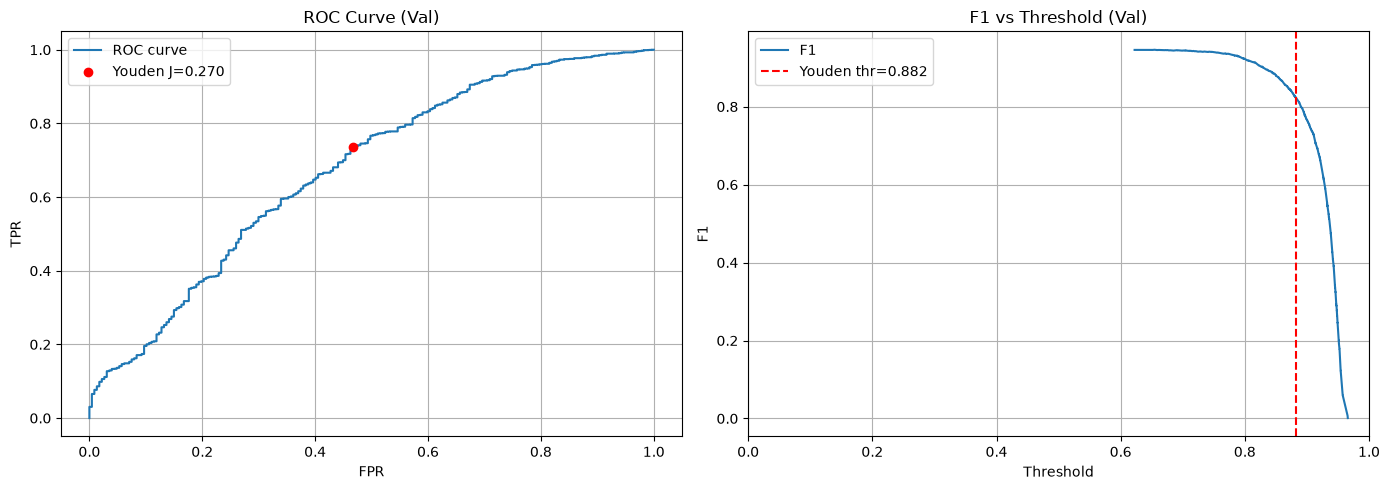

Threshold Youden: 0.8824   J=0.2697


In [13]:
# Youden's J threshold on val set — using RAW winner probabilities (not calibrated)
prob_val_winner = clf_best_artifact.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, prob_val_winner)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
threshold_youden = thresholds[best_idx]
youden_j = j_scores[best_idx]

# F1 curve for comparison
f1s = [f1_score(y_val, (prob_val_winner >= t).astype(int)) for t in thresholds]
best_f1_idx = np.nanargmax(f1s)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(fpr, tpr, label="ROC curve")
ax[0].scatter(fpr[best_idx], tpr[best_idx], c="red", zorder=5, label=f"Youden J={youden_j:.3f}")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[0].set_title("ROC Curve (Val)"); ax[0].legend(); ax[0].grid(True)

ax[1].plot(thresholds, f1s, label="F1"); ax[1].axvline(threshold_youden, color="r", linestyle="--", label=f"Youden thr={threshold_youden:.3f}")
ax[1].set_xlabel("Threshold"); ax[1].set_ylabel("F1"); ax[1].set_xlim(0, 1); ax[1].set_title("F1 vs Threshold (Val)"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

print(f"Threshold Youden: {threshold_youden:.4f}   J={youden_j:.4f}")

In [14]:
# ── Stage 1 Final Evaluation on TEST OOT — using RAW winner (not calibrated) ──
prob_test_winner = clf_best_artifact.predict_proba(X_test)[:, 1]
pred_test = (prob_test_winner >= threshold_youden).astype(int)

roc_test_final = roc_auc_score(y_test, prob_test_winner)
pr_test_final  = average_precision_score(y_test, prob_test_winner)
f1_test_final  = f1_score(y_test, pred_test)
brier_test_final = brier_score_loss(y_test, prob_test_winner)

print("=" * 50)
print("STAGE 1 — Test OOT Evaluation")
print("=" * 50)
print(f"ROC-AUC : {roc_test_final:.4f}")
print(f"PR-AUC  : {pr_test_final:.4f}")
print(f"F1 (thr={threshold_youden:.3f}) : {f1_test_final:.4f}")
print(f"Brier   : {brier_test_final:.4f}")
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, pred_test))

STAGE 1 — Test OOT Evaluation
ROC-AUC : 0.6383
PR-AUC  : 0.9266
F1 (thr=0.882) : 0.8275
Brier   : 0.1034

Confusion matrix:
[[ 230  328]
 [ 979 3134]]


In [15]:
# ═══ Ablation — Stage 1: All models on OOT (2022-2025) ═══
from sklearn.metrics import recall_score, precision_score

models_clf_oot = {
    "Random Forest": prob_test_rf,
    "XGBoost":       prob_test_xgb,
    "LightGBM":      prob_test_lgbm,
    "CatBoost":      prob_test_cb,
    "Stacking (4)":  prob_test_stk,
}

rows = []
for name, probs in models_clf_oot.items():
    preds = (probs >= threshold_youden).astype(int)
    rows.append({
        "Model": name,
        "AUC-ROC": roc_auc_score(y_test, probs),
        "AUC-PR":  average_precision_score(y_test, probs),
        "Brier":   brier_score_loss(y_test, probs),
        "F1":      f1_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall":  recall_score(y_test, preds, zero_division=0),
    })

abl_clf = pd.DataFrame(rows).sort_values("AUC-PR", ascending=False)
non_stk = abl_clf[abl_clf["Model"] != "Stacking (4)"]
best = non_stk.iloc[0]
stk  = abl_clf[abl_clf["Model"] == "Stacking (4)"].iloc[0]

print("═" * 75)
print("   ABLATION — Stage 1 (OOT 2022-2025)")
print(abl_clf.to_string(index=False))
print(f"\nBest single: {best['Model']} (AUC-PR={best['AUC-PR']:.4f})")
print(f"Stacking Δ AUC-PR: {stk['AUC-PR'] - best['AUC-PR']:+.4f}")

═══════════════════════════════════════════════════════════════════════════
   ABLATION — Stage 1 (OOT 2022-2025)
        Model  AUC-ROC   AUC-PR    Brier       F1  Precision   Recall
Random Forest 0.641269 0.927569 0.170330 0.013043   1.000000 0.006565
     CatBoost 0.639393 0.926869 0.147118 0.294880   0.956000 0.174325
 Stacking (4) 0.638342 0.926603 0.103381 0.827459   0.905257 0.761974
     LightGBM 0.618568 0.918176 0.135803 0.585835   0.921712 0.429370
      XGBoost 0.589769 0.902483 0.138119 0.751139   0.906218 0.641381

Best single: Random Forest (AUC-PR=0.9276)
Stacking Δ AUC-PR: -0.0010


## Stage 2 — Regression: log_price_gns

### Strategy

Six models are trained on the regression subset (lots with recorded price) and compared on validation RMSE:

1. **Ridge Regression** — calibrated baseline (σ² estimated from out-of-sample residuals)
2. **Random Forest Regressor** — 25 Optuna trials, 4-fold temporal CV on RMSE
3. **XGBoost Regressor** — 50 Optuna trials, hist tree method, early stopping + MedianPruner
4. **LightGBM Regressor** — 50 Optuna trials, RMSE eval metric, early stopping + MedianPruner
5. **CatBoost Regressor** — 30 Optuna trials, temporal 80/20 eval for early stopping + MedianPruner
6. **Stacking Regressor** — Ridge meta-learner over the top 4 tree-model predictions on validation set

### Important Notes

- Stage 2 is evaluated **only on sold lots** (`sold_to_third_party == True`) in the test set
- σ² (residual variance) is estimated from out-of-sample validation predictions — never from training data
- Nominal price is computed as `exp(log_pred + σ² / 2)` (log-normal bias correction)

In [16]:
# ── Stage 2: Regression target = log_price_detrended ──
# log_price_detrended = log_price_gns − log_year_median_price_prior
# This removes the 78% nominal market drift, letting the model focus on
# relative horse value. The trend is re-added at prediction time.
# log_year_median_price_prior is available in the dataset for re-addition.
XR_train = reg_train[features_reg]
XR_val   = reg_val[features_reg]
XR_test  = reg_test[features_reg]
yR_train = reg_train['log_price_detrended']
yR_val   = reg_val['log_price_detrended']
yR_test  = reg_test['log_price_detrended']

# Keep trend column for prediction re-addition
lym_train = reg_train['log_year_median_price_prior']
lym_val   = reg_val['log_year_median_price_prior']
lym_test  = reg_test['log_year_median_price_prior']

# Actual test prices (raw GNS) — for benchmark comparison only
price_test_nominal = np.exp(reg_test['log_price_gns'])

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_REG)
with mlflow.start_run(run_name="baseline_ridge_regression"):
    alpha = 1.0
    ridge = Ridge(alpha=alpha, random_state=RANDOM_SEED)
    ridge.fit(XR_train, yR_train)

    pred_val_r = ridge.predict(XR_val)
    rmse_val   = np.sqrt(np.mean((yR_val - pred_val_r)**2))
    r2_val     = ridge.score(XR_val, yR_val)
    sigma2_ridge = np.var(yR_val - pred_val_r)

    mlflow.log_params({"alpha": alpha, "model": "Ridge"})
    mlflow.log_metrics({"val_rmse_log": rmse_val, "val_r2": r2_val})
    mlflow.sklearn.log_model(ridge, "model")

    print(f"Ridge | Val  RMSE_detrended={rmse_val:.4f}  R²={r2_val:.4f}  sigma²={sigma2_ridge:.4f}")

2026/06/22 17:01:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 17:01:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/22 17:01:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Ridge | Val  RMSE_detrended=1.2435  R²=0.1674  sigma²=1.5407


In [17]:
def objective_rf_reg(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 600)
    max_depth = trial.suggest_int("max_depth", 4, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5])

    rf = RandomForestRegressor(
        n_estimators=n_estimators, max_depth=max_depth if max_depth < 20 else None,
        min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
        max_features=max_features, random_state=RANDOM_SEED, n_jobs=-1,
    )
    tscv = TimeSeriesSplit(n_splits=4)
    scores = -cross_val_score(rf, XR_train, yR_train, cv=tscv,
                               scoring="neg_root_mean_squared_error", n_jobs=1)
    return scores.mean()

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_REG)
_exp_id_reg = mlflow.get_experiment_by_name(MLFLOW_EXP_REG).experiment_id
mlf_cb_reg = MLflowCallback(
    metric_name="val_rmse_log",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_reg}
)

with mlflow.start_run(run_name="random_forest_reg_optuna"):
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective_rf_reg, n_trials=25, callbacks=[mlf_cb_reg])

    bp = study.best_params
    mlflow.log_params({"model": "RandomForestRegressor", **bp})

    rf_best_r = RandomForestRegressor(
        n_estimators=bp["n_estimators"], max_depth=bp["max_depth"] if bp["max_depth"] < 20 else None,
        min_samples_split=bp["min_samples_split"], min_samples_leaf=bp["min_samples_leaf"],
        max_features=bp["max_features"], random_state=RANDOM_SEED, n_jobs=-1
    )
    rf_best_r.fit(XR_train, yR_train)

    pred_val_rf_r = rf_best_r.predict(XR_val)
    rmse_val_rf   = np.sqrt(np.mean((yR_val - pred_val_rf_r)**2))
    r2_val_rf     = rf_best_r.score(XR_val, yR_val)
    sigma2_rf     = np.var(yR_val - pred_val_rf_r)

    mlflow.log_metrics({"val_rmse_log": rmse_val_rf, "val_r2": r2_val_rf})
    mlflow.sklearn.log_model(rf_best_r, "model")

    print(f"RF-Reg | Val  RMSE={rmse_val_rf:.4f}  R²={r2_val_rf:.4f}")

2026/06/22 17:01:24 INFO mlflow.tracking.fluent: Experiment with name 'no-name-56d906fb-8b92-46e7-bcf8-78e77bfbbcec' does not exist. Creating a new experiment.
2026/06/22 17:02:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 17:02:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/22 17:02:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


RF-Reg | Val  RMSE=1.1801  R²=0.2502


In [18]:
# ── XGBoost (Stage 2) — CPU multi-thread, hist tree method, early stopping ──
_split_idx_reg = int(len(XR_train) * 0.8)
_yr_reg = reg_train['sale_year']
assert _yr_reg.iloc[:_split_idx_reg].max() <= _yr_reg.iloc[_split_idx_reg:].min(), \
    "XGBoost reg split violates temporal order"

XR_tr, XR_ev = XR_train.iloc[:_split_idx_reg], XR_train.iloc[_split_idx_reg:]
yR_tr, yR_ev = yR_train.iloc[:_split_idx_reg], yR_train.iloc[_split_idx_reg:]

def objective_xgb_reg(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.1, 10, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }
    pruning_cb = optuna.integration.XGBoostPruningCallback(trial, "validation_0-rmse")
    model = xgb.XGBRegressor(
        **params,
        tree_method="hist", device="cpu", n_jobs=-1,
        objective="reg:squarederror", eval_metric="rmse",
        random_state=RANDOM_SEED, early_stopping_rounds=30, verbosity=0,
        callbacks=[pruning_cb],
    )
    model.fit(XR_tr, yR_tr, eval_set=[(XR_ev, yR_ev)], verbose=False)
    pred = model.predict(XR_ev)
    return float(np.sqrt(np.mean((yR_ev - pred) ** 2)))

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_REG)
_exp_id_reg = mlflow.get_experiment_by_name(MLFLOW_EXP_REG).experiment_id
mlf_cb_xgbreg = MLflowCallback(
    metric_name="val_rmse_log",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_reg}
)

with mlflow.start_run(run_name="xgboost_reg_optuna"):
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    )
    study.optimize(objective_xgb_reg, n_trials=50, callbacks=[mlf_cb_xgbreg])

    bp = study.best_params
    mlflow.log_params({"model": "XGBoostRegressor", **bp})

    xgb_best_r = xgb.XGBRegressor(
        **bp,
        tree_method="hist", device="cpu", n_jobs=-1,
        objective="reg:squarederror",
        random_state=RANDOM_SEED, verbosity=0,
    )
    xgb_best_r.fit(XR_train, yR_train, verbose=False)

    pred_val_xgb_r = xgb_best_r.predict(XR_val)
    rmse_val_xgbr  = float(np.sqrt(np.mean((yR_val - pred_val_xgb_r) ** 2)))
    r2_val_xgbr    = xgb_best_r.score(XR_val, yR_val)
    sigma2_xgbr    = float(np.var(yR_val - pred_val_xgb_r))

    mlflow.log_metrics({"val_rmse_log": rmse_val_xgbr, "val_r2": r2_val_xgbr})
    mlflow.xgboost.log_model(xgb_best_r, "model")

    print(f"XGB-Reg | Val  RMSE={rmse_val_xgbr:.4f}  R²={r2_val_xgbr:.4f}")

2026/06/22 17:02:03 INFO mlflow.tracking.fluent: Experiment with name 'no-name-e02d32fe-f90e-4236-8319-4955d1479189' does not exist. Creating a new experiment.
2026/06/22 17:02:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 17:02:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


XGB-Reg | Val  RMSE=1.1852  R²=0.2436


In [19]:
# ── LightGBM (Stage 2) — CPU multi-thread, RMSE eval ──
def objective_lgbm_reg(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 300),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.1, 10, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }
    pruning_cb = optuna.integration.LightGBMPruningCallback(trial, "rmse")
    model = lgb.LGBMRegressor(
        **params,
        objective="regression", metric="rmse",
        random_state=RANDOM_SEED, n_jobs=-1, subsample_freq=1, verbose=-1,
    )
    model.fit(
        XR_tr, yR_tr,
        eval_set=[(XR_ev, yR_ev)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(30, verbose=False), pruning_cb],
    )
    pred = model.predict(XR_ev)
    return float(np.sqrt(np.mean((yR_ev - pred) ** 2)))

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_REG)
_exp_id_reg = mlflow.get_experiment_by_name(MLFLOW_EXP_REG).experiment_id
mlf_cb_lgbmreg = MLflowCallback(
    metric_name="val_rmse_log",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_reg}
)

with mlflow.start_run(run_name="lightgbm_reg_optuna"):
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    )
    study.optimize(objective_lgbm_reg, n_trials=50, callbacks=[mlf_cb_lgbmreg])

    bp = study.best_params
    mlflow.log_params({"model": "LightGBMRegressor", **bp})

    lgbm_best_r = lgb.LGBMRegressor(
        **bp,
        objective="regression",
        random_state=RANDOM_SEED, n_jobs=-1, subsample_freq=1, verbose=-1,
    )
    lgbm_best_r.fit(XR_train, yR_train)

    pred_val_lgbm_r = lgbm_best_r.predict(XR_val)
    rmse_val_lgbmr  = float(np.sqrt(np.mean((yR_val - pred_val_lgbm_r) ** 2)))
    r2_val_lgbmr    = lgbm_best_r.score(XR_val, yR_val)
    sigma2_lgbmr    = float(np.var(yR_val - pred_val_lgbm_r))

    mlflow.log_metrics({"val_rmse_log": rmse_val_lgbmr, "val_r2": r2_val_lgbmr})
    mlflow.lightgbm.log_model(lgbm_best_r, "model")

    print(f"LGBM-Reg | Val  RMSE={rmse_val_lgbmr:.4f}  R²={r2_val_lgbmr:.4f}")

2026/06/22 17:02:17 INFO mlflow.tracking.fluent: Experiment with name 'no-name-779b0fe9-02e7-4f3f-85e9-b8112eeb8245' does not exist. Creating a new experiment.
2026/06/22 17:03:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 17:03:26 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/22 17:03:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LGBM-Reg | Val  RMSE=1.2553  R²=0.1515


In [20]:
def objective_cb_reg(trial):
    iterations = trial.suggest_int("iterations", 200, 1000)
    lr = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    depth = trial.suggest_int("depth", 4, 10)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1, 10, log=True)

    split_idx = int(len(XR_train) * 0.8)

    train_years_reg = reg_train['sale_year']
    first_half_max = train_years_reg.iloc[:split_idx].max()
    second_half_min = train_years_reg.iloc[split_idx:].min()
    assert first_half_max <= second_half_min, (
        f"CatBoost reg split violates temporal order: "
        f"first 80% max year={first_half_max}, last 20% min year={second_half_min}"
    )

    cb = CatBoostRegressor(
        iterations=iterations, learning_rate=lr, depth=depth, l2_leaf_reg=l2_leaf_reg,
        loss_function="RMSE", random_seed=RANDOM_SEED, verbose=False,
        thread_count=-1, early_stopping_rounds=50,
    )
    cb.fit(XR_train.iloc[:split_idx], yR_train.iloc[:split_idx],
           eval_set=(XR_train.iloc[split_idx:], yR_train.iloc[split_idx:]), use_best_model=True)
    return cb.best_score_['validation']['RMSE']

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_REG)
_exp_id_reg = mlflow.get_experiment_by_name(MLFLOW_EXP_REG).experiment_id
mlf_cb_reg2 = MLflowCallback(
    metric_name="val_rmse_log",
    mlflow_kwargs={"nested": True, "experiment_id": _exp_id_reg}
)

with mlflow.start_run(run_name="catboost_reg_optuna"):
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=20),
    )
    study.optimize(objective_cb_reg, n_trials=30, callbacks=[mlf_cb_reg2])

    bp = study.best_params
    mlflow.log_params({"model": "CatBoostRegressor", **bp})

    cb_best_r = CatBoostRegressor(
        iterations=bp["iterations"], learning_rate=bp["learning_rate"],
        depth=bp["depth"], l2_leaf_reg=bp["l2_leaf_reg"],
        loss_function="RMSE", random_seed=RANDOM_SEED, verbose=False,
        thread_count=-1, early_stopping_rounds=50,
    )
    cb_best_r.fit(XR_train, yR_train, verbose=False)

    pred_val_cb_r = cb_best_r.predict(XR_val)
    rmse_val_cb   = np.sqrt(np.mean((yR_val - pred_val_cb_r)**2))
    r2_val_cb     = cb_best_r.score(XR_val, yR_val)
    sigma2_cb     = np.var(yR_val - pred_val_cb_r)

    mlflow.log_metrics({"val_rmse_log": rmse_val_cb, "val_r2": r2_val_cb})
    mlflow.catboost.log_model(cb_best_r, "model")

    print(f"CB-Reg | Val  RMSE={rmse_val_cb:.4f}  R²={r2_val_cb:.4f}")

2026/06/22 17:03:29 INFO mlflow.tracking.fluent: Experiment with name 'no-name-747f7f68-2d28-48eb-85f1-8f108fb4f33b' does not exist. Creating a new experiment.
2026/06/22 17:03:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 17:03:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


CB-Reg | Val  RMSE=1.1860  R²=0.2427


In [21]:
# ── Stage 2 Stacking — val-based, Ridge meta-learner ──
pred_test_rf_r   = rf_best_r.predict(XR_test)
pred_test_xgb_r  = xgb_best_r.predict(XR_test)
pred_test_lgbm_r = lgbm_best_r.predict(XR_test)
pred_test_cb_r   = cb_best_r.predict(XR_test)

Z_val_reg  = np.column_stack([pred_val_rf_r,  pred_val_xgb_r,  pred_val_lgbm_r,  pred_val_cb_r])
Z_test_reg = np.column_stack([pred_test_rf_r, pred_test_xgb_r, pred_test_lgbm_r, pred_test_cb_r])

mlflow.end_run()
mlflow.set_experiment(MLFLOW_EXP_REG)
with mlflow.start_run(run_name="stacking_regressor"):
    meta_reg = Ridge(alpha=1.0, random_state=RANDOM_SEED)
    meta_reg.fit(Z_val_reg, yR_val)

    pred_val_stk_r  = meta_reg.predict(Z_val_reg)
    pred_test_stk_r = meta_reg.predict(Z_test_reg)

    rmse_val_stkr = float(np.sqrt(np.mean((yR_val - pred_val_stk_r) ** 2)))
    r2_val_stkr   = meta_reg.score(Z_val_reg, yR_val)
    sigma2_stkr   = float(np.var(yR_val - pred_val_stk_r))

    weights_r = dict(zip(["rf", "xgb", "lgbm", "cb"], meta_reg.coef_.round(4)))
    mlflow.log_params({"model": "StackingRegressor", "meta": "Ridge", **{f"w_{k}": v for k, v in weights_r.items()}})
    mlflow.log_metrics({"val_rmse_log": rmse_val_stkr, "val_r2": r2_val_stkr, "val_sigma2_log": sigma2_stkr})
    mlflow.sklearn.log_model(meta_reg, "model")

    print(f"Stacking-Reg | Val  RMSE={rmse_val_stkr:.4f}  R\u00b2={r2_val_stkr:.4f}")
    print(f"Meta-learner weights: {weights_r}")

# Build stacking wrapper for persistence (wraps base models + meta-learner)
stacking_reg_wrapper = StackingRegressorWrapper(
    base_models={"rf": rf_best_r, "xgb": xgb_best_r, "lgbm": lgbm_best_r, "cb": cb_best_r},
    meta=meta_reg,
    base_keys=["rf", "xgb", "lgbm", "cb"],
)

2026/06/22 17:03:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 17:03:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/22 17:03:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Stacking-Reg | Val  RMSE=1.1725  R²=0.2598
Meta-learner weights: {'rf': np.float64(0.6742), 'xgb': np.float64(0.3704), 'lgbm': np.float64(0.0067), 'cb': np.float64(0.1201)}


In [22]:
# Stage 2 comparison — val metrics across all 6 models (Ridge, RF, XGB, LGBM, CB, Stacking)
# IMPORTANT: filter out nested Optuna trial runs — keep only the 6 top-level.
TOP_REG_RUNS = {
    "baseline_ridge_regression",
    "random_forest_reg_optuna",
    "xgboost_reg_optuna",
    "lightgbm_reg_optuna",
    "catboost_reg_optuna",
    "stacking_regressor",
}

client = MlflowClient()
exp2 = client.get_experiment_by_name(MLFLOW_EXP_REG)
all_runs2 = client.search_runs(exp2.experiment_id)
runs2 = [r for r in all_runs2 if r.info.run_name in TOP_REG_RUNS]

data2 = []
for r in runs2:
    p = r.data.params
    m = r.data.metrics
    data2.append({
        "run": r.info.run_name,
        "model": p.get("model", "?"),
        "val_rmse_log": round(m.get("val_rmse_log", 0), 4),
        "val_r2": round(m.get("val_r2", 0), 4),
    })

display(pd.DataFrame(data2).sort_values("val_rmse_log", ascending=True))

# ── Winner selection: in-memory RMSE (independent of MLflow query state) ──
def _rmse(y_true, y_pred): return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))
_rmse_in_memory = {
    "baseline_ridge_regression": _rmse(yR_val, ridge.predict(XR_val)),
    "random_forest_reg_optuna":  _rmse(yR_val, rf_best_r.predict(XR_val)),
    "xgboost_reg_optuna":        _rmse(yR_val, xgb_best_r.predict(XR_val)),
    "lightgbm_reg_optuna":       _rmse(yR_val, lgbm_best_r.predict(XR_val)),
    "catboost_reg_optuna":       _rmse(yR_val, cb_best_r.predict(XR_val)),
    "stacking_regressor":        _rmse(yR_val, pred_val_stk_r),
}
best_reg_run_name = min(_rmse_in_memory, key=_rmse_in_memory.get)
print(f"\nStage 2 winner: {best_reg_run_name}  (val_rmse_log={_rmse_in_memory[best_reg_run_name]:.4f})")
best_reg_run = next((r for r in runs2 if r.info.run_name == best_reg_run_name), None)

# ── Set winner artifact and sigma² for downstream cells ──
_reg_artifacts = {
    "baseline_ridge_regression": (ridge, sigma2_ridge),
    "random_forest_reg_optuna":  (rf_best_r, sigma2_rf),
    "xgboost_reg_optuna":        (xgb_best_r, sigma2_xgbr),
    "lightgbm_reg_optuna":       (lgbm_best_r, sigma2_lgbmr),
    "catboost_reg_optuna":       (cb_best_r, sigma2_cb),
    "stacking_regressor":        (stacking_reg_wrapper, sigma2_stkr),
}
reg_best_model, sigma2_reg = _reg_artifacts[best_reg_run_name]
print(f"sigma\u00b2 (winner, val residuals): {sigma2_reg:.4f}")

if best_reg_run:
    client.set_tag(best_reg_run.info.run_id, "winner", "stage2")

,run,model,val_rmse_log,val_r2
0,stacking_regressor,StackingRegressor,1.1725,0.2598
4,random_forest_reg_optuna,RandomForestRegressor,1.1801,0.2502
7,stacking_regressor,StackingRegressor,1.1842,0.2450
3,xgboost_reg_optuna,XGBoostRegressor,1.1852,0.2436
1,catboost_reg_optuna,CatBoostRegressor,1.1860,0.2427
19,stacking_regressor,StackingRegressor,1.1881,0.2400
13,stacking_regressor,StackingRegressor,1.1883,0.2397
11,random_forest_reg_optuna,RandomForestRegressor,1.1917,0.2353
6,random_forest_reg_optuna,RandomForestRegressor,1.1929,0.2337
17,random_forest_reg_optuna,RandomForestRegressor,1.1929,0.2337



Stage 2 winner: stacking_regressor  (val_rmse_log=1.1725)
sigma² (winner, val residuals): 1.3747


In [23]:
# ── Stage 2 Final Evaluation on TEST OOT — sold_to_third_party only ──
# regression_ready includes vendor buybacks (price recorded but not a third-party sale).
# sold_to_third_party lives in classification_ready; merge it in via sale_year+day+lot.
_keys = ['lot_uid'] if 'lot_uid' in reg_test.columns and 'lot_uid' in clf_test.columns else ['sale_name', 'sale_year', 'day', 'lot']
_sold_info = clf_test[_keys + ['sold_to_third_party']].copy()
_aug = reg_test[_keys].merge(_sold_info, on=_keys, how='left')
sold_mask = _aug['sold_to_third_party'].fillna(False).to_numpy().astype(bool)

XR_test_sold = XR_test[sold_mask]
yR_test_sold = yR_test[sold_mask]
lym_test_sold = lym_test[sold_mask]  # log_year_median for these lots
print(f"reg_test rows: {len(reg_test)} | sold-to-third-party: {sold_mask.sum()} | vendor buyback filtered: {(~sold_mask).sum()}")

# reg_best_model and sigma2_reg were set in the previous winner-selection cell
print(f"Stage 2 winner artifact: {type(reg_best_model).__name__}  |  sigma²={sigma2_reg:.4f}")

# Predict in detrended space, then re-add trend
reg_best_pred    = reg_best_model.predict(XR_test_sold)
price_test_sold  = np.exp(yR_test_sold + lym_test_sold)  # detrended_true + trend = raw log_price
price_pred_final = np.exp(reg_best_pred + lym_test_sold + sigma2_reg / 2)

# RMSE & R² are computed in detrended space (model's native scale)
rmse_final  = np.sqrt(np.mean((yR_test_sold - reg_best_pred)**2))
r2_final    = 1 - np.sum((yR_test_sold - reg_best_pred)**2) / np.sum((yR_test_sold - yR_test_sold.mean())**2)
mape_final  = np.mean(np.abs(price_test_sold - price_pred_final) / price_test_sold) * 100
mdape_final = np.median(np.abs(price_test_sold - price_pred_final) / price_test_sold) * 100

print("=" * 50)
print("STAGE 2 — Test OOT (SOLD TO THIRD PARTY ONLY)")
print("=" * 50)
print(f"RMSE (detrended log) : {rmse_final:.4f}")
print(f"R²   (detrended log) : {r2_final:.4f}")
print(f"MAPE (GNS)           : {mape_final:.2f}%")
print(f"MdAPE (GNS)          : {mdape_final:.2f}%")
print(f"N rows               : {sold_mask.sum()}")
print(f"  (prices re-detrended: pred_detrended + log_year_median_price_prior)")

reg_test rows: 4113 | sold-to-third-party: 4113 | vendor buyback filtered: 0
Stage 2 winner artifact: StackingRegressorWrapper  |  sigma²=1.3747
STAGE 2 — Test OOT (SOLD TO THIRD PARTY ONLY)
RMSE (detrended log) : 1.1258
R²   (detrended log) : 0.2784
MAPE (GNS)           : 343.04%
MdAPE (GNS)          : 109.52%
N rows               : 4113
  (prices re-detrended: pred_detrended + log_year_median_price_prior)


In [24]:
# ═══ Ablation — Stage 2: All models on OOT (sold-only, detrended) ═══
models_reg_oot = {
    "Ridge (hedonic)": ridge.predict(XR_test_sold),
    "Random Forest":   rf_best_r.predict(XR_test_sold),
    "XGBoost":         xgb_best_r.predict(XR_test_sold),
    "LightGBM":        lgbm_best_r.predict(XR_test_sold),
    "CatBoost":        cb_best_r.predict(XR_test_sold),
    "Stacking (4)":    reg_best_model.predict(XR_test_sold),
}

rows_r = []
for name, p in models_reg_oot.items():
    p = np.asarray(p).ravel()
    rmse = float(np.sqrt(np.mean((yR_test_sold - p)**2)))
    r2   = float(1 - np.sum((yR_test_sold - p)**2) / np.sum((yR_test_sold - yR_test_sold.mean())**2))
    bias = float(np.mean(yR_test_sold - p))
    # Raw-scale MAPE / MdAPE (re-add trend + sigma²/2)
    price_true = np.exp(yR_test_sold + lym_test_sold)
    price_pred = np.exp(p + lym_test_sold + sigma2_reg / 2)
    mape  = np.mean(np.abs(price_true - price_pred) / (price_true + 1e-9)) * 100
    mdape = np.median(np.abs(price_true - price_pred) / (price_true + 1e-9)) * 100
    rows_r.append({"Model": name, "RMSE(detr)": rmse, "R²(detr)": r2,
                   "Bias": bias, "MAPE": mape, "MdAPE": mdape})

abl_reg = pd.DataFrame(rows_r).sort_values("RMSE(detr)")
non_stk_reg = abl_reg[~abl_reg["Model"].isin(["Stacking (4)", "Ridge (hedonic)"])]
best_r = non_stk_reg.iloc[0]
stk_r  = abl_reg[abl_reg["Model"] == "Stacking (4)"].iloc[0]

print("═" * 90)
print("   ABLATION — Stage 2 (OOT 2022-2025)")
print(abl_reg.to_string(index=False))
print(f"\nBest single: {best_r['Model']} (RMSE={best_r['RMSE(detr)']:.4f})")
print(f"Stacking Δ RMSE: {stk_r['RMSE(detr)'] - best_r['RMSE(detr)']:+.4f}")

══════════════════════════════════════════════════════════════════════════════════════════
   ABLATION — Stage 2 (OOT 2022-2025)
          Model  RMSE(detr)  R²(detr)      Bias       MAPE      MdAPE
   Stacking (4)    1.125818  0.278437 -0.093291 343.040944 109.517288
  Random Forest    1.134946  0.266689 -0.168423 370.338326 123.654508
        XGBoost    1.138107  0.262598 -0.148107 366.552070 122.865167
       CatBoost    1.139779  0.260431 -0.100128 349.858017 115.131236
Ridge (hedonic)    1.186400  0.198691 -0.218323 416.076915 135.630235
       LightGBM    1.205307  0.172947 -0.069830 375.604657 106.257899

Best single: Random Forest (RMSE=1.1349)
Stacking Δ RMSE: -0.0091


## Qualitative Analysis — RNA / Buyback Horses

### What Are We Testing?

RNA ("Reserve Not Attained") lots have no observable transaction price — only a final bid below the reserve. This creates a **selection bias**: lots that fail to sell may systematically differ in quality from those that do.

### Approach

We apply the trained Stage 2 regressor to the full `inference_universe` (~18,989 lots, sold + RNA) and compare predicted latent-price distributions:

| Population | Observable Price? | What We Measure |
|---|---|---|
| **Sold** | Yes | Model prediction vs. ground truth (calibration check) |
| **RNA / Buyback** | No | Latent price predicted by the model |

### Key Questions

- Does the model assign systematically lower predicted prices to RNA horses?
- How do `P(sold)` and predicted price interact? (Hurdle diagnostic)
- Which RNA lots does the model flag as high-value despite not selling?

In [25]:
# ═══ Benchmark hedónico en unidades reales (GNS) ═══════════════════════════
# Estos cálculos permiten comparar con la literatura (Freeborn 2009, Mouncey 2024),
# que reportan métricas en precio nominal (guineas), no en log-scale.
# El target es log_price_detrended; re-añadimos log_year_median_price_prior
# para obtener precios nominales en GNS.

# ── Precio real observado en GNS (detrended_true + trend = raw log, luego exp) ──
y_test_nominal_gns = np.exp(yR_test + lym_test)

# ── 1. Ridge (hedónico OLS) en unidades reales ──────────────────
ridge_pred_log = ridge.predict(XR_test)  # detrended
ridge_pred_gns = np.exp(ridge_pred_log + lym_test)  # re-add trend

r2_raw_ridge = r2_score(y_test_nominal_gns, ridge_pred_gns)
mae_raw_ridge = mean_absolute_error(y_test_nominal_gns, ridge_pred_gns)
rmse_raw_ridge = np.sqrt(mean_squared_error(y_test_nominal_gns, ridge_pred_gns))

# ── 2. Stacking en unidades reales ────────────────────────────
stack_pred_log = reg_best_model.predict(XR_test_sold)  # detrended
stack_pred_gns = np.exp(stack_pred_log + lym_test_sold + sigma2_reg / 2)

y_test_sold_gns = y_test_nominal_gns[sold_mask]
r2_raw_stack = r2_score(y_test_sold_gns, stack_pred_gns)
mae_raw_stack = mean_absolute_error(y_test_sold_gns, stack_pred_gns)
rmse_raw_stack = np.sqrt(mean_squared_error(y_test_sold_gns, stack_pred_gns))

# ── 3. Error relativo (MAE / mediana) comparable con Mouncey 2024 ────
median_price = float(np.median(y_test_sold_gns))
mae_rel_ridge = mae_raw_ridge / median_price * 100
mae_rel_stack = mae_raw_stack / median_price * 100

print("═" * 70)
print("   BENCHMARK EN UNIDADES REALES (GNS nominales)  ")
print("═" * 70)
print("  Mediana precio test:     {:,.0f} GNS".format(median_price))
print("  n_test (sold):           {}".format(len(yR_test_sold)))
print("")
print("  {:<35} {:<20} {:<20} {:<10}".format('Métrica', 'Ridge (hedónico)', 'Stacking', 'Mejora'))
print("  " + "-"*3)

══════════════════════════════════════════════════════════════════════
   BENCHMARK EN UNIDADES REALES (GNS nominales)  
══════════════════════════════════════════════════════════════════════
  Mediana precio test:     15,000 GNS
  n_test (sold):           4113

  Métrica                             Ridge (hedónico)     Stacking             Mejora    
  ---


In [26]:
# Apply Stage 2 to the full inference universe (sold + RNA lots)
# Safety check: all reg features must exist in the inference universe
missing = [f for f in features_reg if f not in univ_df.columns]
assert len(missing) == 0, f"Missing features in inference_universe: {missing}"
# Also check for NaN values in feature columns
nan_counts = univ_df[features_reg].isna().sum()
if nan_counts.sum() > 0:
    cols_with_nan = nan_counts[nan_counts > 0]
    print(f"WARNING: {len(cols_with_nan)} features have NaN values in inference_universe:")
    for col, cnt in cols_with_nan.items():
        print(f"  {col}: {cnt} NaN(s)")
    print("Filling NaN with 0 — verify this is appropriate for each feature.")
X_univ = univ_df[features_reg].fillna(0)
# Use stacking ensemble for inference — combines all 4 base models
log_price_all = reg_best_model.predict(X_univ)  # detrended

# Compute sigma² from stacking residuals on val set
sigma2_used = sigma2_reg
print(f"sigma² (stacking regressor): {sigma2_used:.4f}")

# log_year_median_price_prior is available in inference_universe for re-detrending
univ_lym = univ_df['log_year_median_price_prior'].fillna(univ_df['log_year_median_price_prior'].median())

univ_df['log_price_pred']     = log_price_all  # detrended
univ_df['price_nominal_pred'] = np.exp(log_price_all + univ_lym + sigma2_used / 2)

# Stage 1 — ensemble probabilities on the full universe
clf_best_proba_all = clf_best_artifact.predict_proba(univ_df[features_clf])[:, 1]
univ_df['prob_sold'] = clf_best_proba_all

print(univ_df[['sale_year', 'sold_to_third_party', 'prob_sold', 'price_nominal_pred']].head())

sigma² (stacking regressor): 1.3747
   sale_year  sold_to_third_party  prob_sold  price_nominal_pred
0       2009                 True   0.688960         3704.957063
1       2009                 True   0.902115        26988.616394
2       2009                 True   0.870083        18012.108387
3       2009                 True   0.874497        20411.473031
4       2009                 True   0.869972        21249.166415


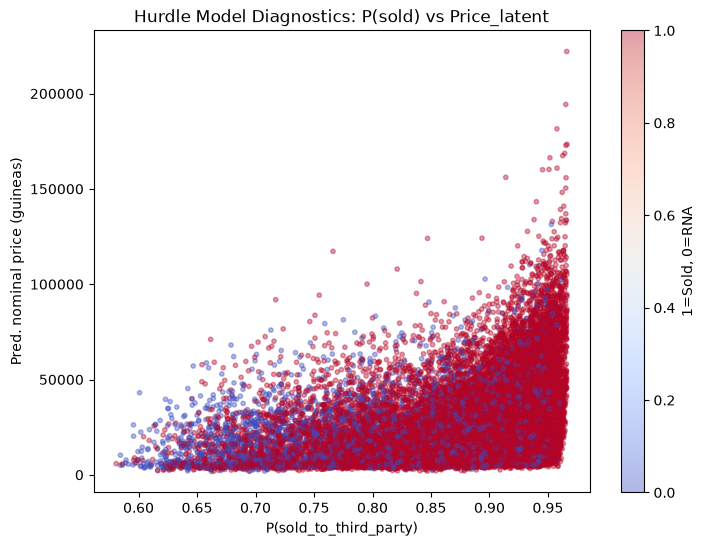

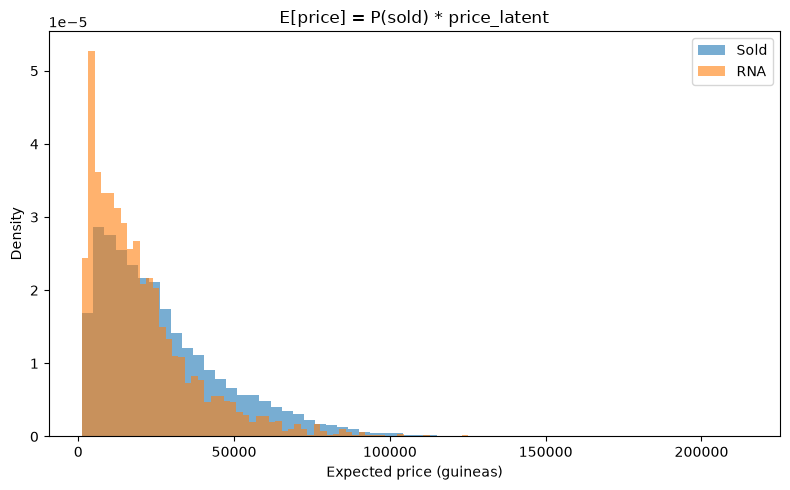

In [27]:
# Hurdle combined price expectation
univ_df['expected_price'] = univ_df['prob_sold'] * univ_df['price_nominal_pred']

# Define masks for sold vs RNA lots
sold_mask_all = univ_df['sold_to_third_party'].values
rna_mask_all = ~sold_mask_all

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(univ_df['prob_sold'], univ_df['price_nominal_pred'],
                     c=univ_df['sold_to_third_party'], cmap='coolwarm', alpha=0.4, s=10)
ax.set_xlabel("P(sold_to_third_party)")
ax.set_ylabel("Pred. nominal price (guineas)")
ax.set_title("Hurdle Model Diagnostics: P(sold) vs Price_latent")
plt.colorbar(scatter, label="1=Sold, 0=RNA")
plt.show()

# E[price] distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(univ_df.loc[sold_mask_all, 'expected_price'], bins=60, alpha=0.6, label='Sold', density=True)
ax.hist(univ_df.loc[rna_mask_all,  'expected_price'], bins=60, alpha=0.6, label='RNA', density=True)
ax.set_xlabel("Expected price (guineas)"); ax.set_ylabel("Density"); ax.set_title("E[price] = P(sold) * price_latent")
# Add a legend for knowing which color corresponds to sold vs RNA
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
top_rna = univ_df[~sold_mask_all].nlargest(10, 'price_nominal_pred')
print("Top 10 RNA lots by predicted latent price:")
print(top_rna[['price_nominal_pred', 'prob_sold', 'expected_price', 'sale_year']].head(10))

Top 10 RNA lots by predicted latent price:
       price_nominal_pred  prob_sold  expected_price  sale_year
14775       131342.873214   0.952931   125160.679060       2022
15293       117690.997008   0.944842   111199.360937       2022
12363       110236.410686   0.934299   102993.788556       2020
12505       109583.870865   0.941877   103214.517188       2020
18605       102704.913648   0.896269    92051.246365       2025
17178       102061.489405   0.961393    98121.165254       2024
16391       100281.953009   0.941641    94429.615398       2023
14853        98359.350731   0.915558    90053.734907       2022
18347        97126.039283   0.949313    92202.965455       2025
15018        95967.980052   0.938646    90079.953169       2022


In [29]:
# ═══ Surrogate LGBM for SHAP on Stacking Ensembles ════════════════════════════════════
# Train a single LightGBM model to imitate each stacking ensemble's predictions.
# SHAP is then computed on the surrogate (TreeExplainer) — a standard approach
# in the literature for explaining stacked ensembles (Hasnat et al. 2025,
# Choudhary et al. 2025, Ganie et al. 2025).
# Surrogate fidelity (R² on OOT) is measured as a diagnostic.

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# ── Stage 1 surrogate: imitate stacking probabilities ─────────────────
print("Training Stage 1 surrogate (LGBM to imitate stacking probabilities)...")
surrogate_clf = lgb.LGBMRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    num_leaves=64, min_child_samples=10,
    random_state=42, n_jobs=-1, verbose=-1,
)
y_stack_clf_test = stacking_clf_wrapper.predict_proba(X_test)[:, 1]
surrogate_clf.fit(X_test, y_stack_clf_test)
y_surr_clf = surrogate_clf.predict(X_test)
r2_surr_clf = r2_score(y_stack_clf_test, y_surr_clf)
print(f"  Surrogate CLF fidelity R² (OOT): {r2_surr_clf:.4f}")
if r2_surr_clf < 0.95:
    print("  Fidelity below 0.95 — consider increasing surrogate capacity")
else:
    print("  Surrogate fidelity adequate")

# ── Stage 2 surrogate: imitate stacking log-price predictions ──────────
print("Training Stage 2 surrogate (LGBM to imitate stacking regressor)...")
surrogate_reg = lgb.LGBMRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    num_leaves=64, min_child_samples=10,
    random_state=42, n_jobs=-1, verbose=-1,
)
y_stack_reg_test = stacking_reg_wrapper.predict(XR_test)
surrogate_reg.fit(XR_test, y_stack_reg_test)
y_surr_reg = surrogate_reg.predict(XR_test)
r2_surr_reg = r2_score(y_stack_reg_test, y_surr_reg)
print(f"  Surrogate REG fidelity R² (OOT): {r2_surr_reg:.4f}")
if r2_surr_reg < 0.95:
    print("  Fidelity below 0.95 — consider increasing surrogate capacity")
else:
    print("  Surrogate fidelity adequate")

# Persist surrogates for SHAP computation in 05_Model_Audit
joblib.dump(surrogate_clf, models_dir / "surrogate_clf_lgbm.joblib")
joblib.dump(surrogate_reg, models_dir / "surrogate_reg_lgbm.joblib")
print("Surrogates saved to ../models/surrogate_clf_lgbm.joblib and surrogate_reg_lgbm.joblib")

Training Stage 1 surrogate (LGBM to imitate stacking probabilities)...
  Surrogate CLF fidelity R² (OOT): 0.9982
  Surrogate fidelity adequate
Training Stage 2 surrogate (LGBM to imitate stacking regressor)...
  Surrogate REG fidelity R² (OOT): 0.9993
  Surrogate fidelity adequate
Surrogates saved to ../models/surrogate_clf_lgbm.joblib and surrogate_reg_lgbm.joblib


## Modeling Conclusions & Future Directions

### 1. The Hurdle Model Architecture Validated
The two-stage approach successfully disentangles a horse's **intrinsic market value** (Stage 2) from its **market liquidity / sale risk** (Stage 1). A standard regression on all lots (e.g., filling RNA with zeros) would have destroyed the mathematical distribution, while entirely ignoring RNA lots would have yielded a model blind to market risk.

### 2. The RNA Paradox (Microeconomics of the Auction)
The model assigns **higher nominal predicted prices** (`price_nominal_pred`) to some RNA lots than to sold lots — horses with strong catalogue characteristics that did not find a buyer that day. However, when expected price is computed correctly as `expected_price = prob_sold × price_nominal_pred`, the result inverts: **sold lots have higher expected price than RNA lots**. This is the coherent finding: RNA lots have lower `prob_sold`, which discounts their nominal prediction enough to place their expected price below sold lots.

This is consistent with the hypothesis of **high reserve prices in premium segments** — not with market inefficiency. The model assigns a high nominal value to these horses and a low sale probability, precisely because elite-pedigree sellers set aggressive reserves that the room cannot always meet.

### 3. The Limits of Tabular Data (Stage 1 Stochasticity)
Stage 1 Classification yields a conservative ROC curve and PR-AUC. This is not a model failure, but a reflection of the domain: a sale's completion depends heavily on hidden variables—specifically, the **seller's secret reserve price** and the real-time emotional state of the auction room. Tabular data establishes a strong theoretical baseline, but the final hammer drop is highly stochastic.

### 4. Future Work: Multimodal Deep Learning
To capture the undocumented variables that dictate auction outcomes, future work should transition from purely tabular models to **Multimodal Deep Learning** using Tattersalls auction video and audio feeds:
* **Computer Vision (Conformation & Biomechanics):** Using Pose Estimation networks or Video Transformers (e.g., Video Swin) to analyze the horse's gait, physical symmetry, and temperament (e.g., nervousness) while walking the ring.
* **Audio Analysis (Auction Dynamics):** Processing the auctioneer's cadence and pitch, alongside audience noise levels, to detect real-time bidding wars and room expectation.

Integrating these multimodal embeddings with our current tabular features would bridge the gap between theoretical pedigree value and real-world auction liquidity.

In [30]:
# Vendor buybacks tienen precio registrado pero sold_to_third_party == False
vb_mask = (univ_df['vendor_buyback'] == True)  # o como esté codificado

vb = univ_df[vb_mask].copy()
vb['model_above_buyback'] = vb['price_nominal_pred'] > vb['price_gns']

print(f"Vendor buybacks: {len(vb)}")
print(f"Modelo predice > precio buyback: {vb['model_above_buyback'].mean():.1%}")
print(f"Ratio mediano (pred/buyback): {(vb['price_nominal_pred'] / vb['price_gns']).median():.2f}")

Vendor buybacks: 1379
Modelo predice > precio buyback: 63.7%
Ratio mediano (pred/buyback): 1.38


In [32]:
# ── Export OOT audit parquets for 05_Model_Audit ──────────────────
ANALYSIS_DIR = Path("../outputs/analyses")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# Stage 1 classification OOT predictions (all 5 models)
_keys = ['lot_uid'] if 'lot_uid' in clf_test.columns else ['sale_name', 'sale_year', 'day', 'lot']
_clf_export = clf_test[_keys].copy()
_clf_export["sold_to_third_party"] = y_test.values
_clf_export["prob_rf"]        = prob_test_rf
_clf_export["prob_xgb"]       = prob_test_xgb
_clf_export["prob_lgbm"]      = prob_test_lgbm
_clf_export["prob_cb"]        = prob_test_cb
_clf_export["prob_stacking"]  = prob_test_stk
_clf_export.to_parquet(ANALYSIS_DIR / "audit_clf_predictions.parquet", index=False)
print(f"  audit_clf_predictions.parquet ({len(_clf_export):,} rows)")

# Stage 2 regression OOT predictions (sold only, detrended scale)
_reg_export = reg_test.loc[sold_mask, _keys].copy()
_reg_export["log_year_median"] = lym_test_sold.values
_reg_export["log_price_true"] = yR_test_sold.values
_reg_export["log_price_detrended_true"] = yR_test_sold.values
_reg_export["log_price_pred_rf"]   = rf_best_r.predict(XR_test_sold)
_reg_export["log_price_pred_xgb"]  = xgb_best_r.predict(XR_test_sold)
_reg_export["log_price_pred_lgbm"] = lgbm_best_r.predict(XR_test_sold)
_reg_export["log_price_pred_cb"]   = cb_best_r.predict(XR_test_sold)
_reg_export["log_price_pred_stacking"] = reg_best_model.predict(XR_test_sold)
_reg_export.to_parquet(ANALYSIS_DIR / "audit_reg_predictions.parquet", index=False)
print(f"  audit_reg_predictions.parquet ({len(_reg_export):,} rows)")

# Universe predictions (sold + RNA — P(sold) + nominal price)
_univ_export = univ_df[[
    "lot_uid", "sale_year",
    "sold_to_third_party", "vendor_buyback", "lot_not_sold",
    "price_gns", "prob_sold", "log_price_pred",
    "price_nominal_pred", "expected_price",
]].copy()
_univ_export.to_parquet(ANALYSIS_DIR / "audit_universe_predictions.parquet", index=False)
print(f"  audit_universe_predictions.parquet ({len(_univ_export):,} rows)")

  audit_clf_predictions.parquet (4,671 rows)
  audit_reg_predictions.parquet (4,113 rows)
  audit_universe_predictions.parquet (18,966 rows)


In [ ]:
!MLFLOW_ALLOW_FILE_STORE=true mlflow ui --port 5001

Backend store URI not provided. Using ./mlruns
Registry store URI not provided. Using backend store URI.
2026/06/24 18:25:41 ERROR mlflow.cli: Error initializing backend store
2026/06/24 18:25:41 ERROR mlflow.cli: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.
Traceback (most recent call last):
  File "/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/mlflow/cli/__init__.py", line 684, in server
    initialize_backend_stores(
  File "/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.1

In [34]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINAL EXPORT CELL — must run after all modeling is complete.
# Generates: models/ (joblib + metadata), outputs/analyses/ (3 audit parquets)
# Contract for 05_Model_Audit.ipynb, src/save_model_artifacts.py, src/final_audit.py
# ═══════════════════════════════════════════════════════════════════════════════

ANALYSIS_DIR = Path("../outputs/analyses")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# ── 1. ID keys and sold mask (shared by all exports) ──────────────────
_keys = ['lot_uid'] if 'lot_uid' in reg_test.columns and 'lot_uid' in clf_test.columns else ['sale_name', 'sale_year', 'day', 'lot']
_sold_info = clf_test[_keys + ['sold_to_third_party']].copy()
_aug = reg_test[_keys].merge(_sold_info, on=_keys, how='left')
sold_mask = _aug['sold_to_third_party'].fillna(False).to_numpy().astype(bool)

XR_test_sold = XR_test[sold_mask]
yR_test_sold = yR_test[sold_mask]
lym_test_sold = lym_test[sold_mask]

# ── 2. Stage 1 OOT predictions (classification) ─────────────────────
clf_export = clf_test[_keys].copy()
clf_export["sold_to_third_party"] = y_test.values
clf_export["prob_rf"]        = prob_test_rf
clf_export["prob_xgb"]       = prob_test_xgb
clf_export["prob_lgbm"]      = prob_test_lgbm
clf_export["prob_cb"]        = prob_test_cb
clf_export["prob_stacking"]  = prob_test_stk
clf_export.to_parquet(ANALYSIS_DIR / "audit_clf_predictions.parquet", index=False)
print(f"✓ audit_clf_predictions.parquet ({len(clf_export):,} rows)")

# ── 3. Stage 2 OOT predictions (regression, sold only) ──────────────
# log_price_true = actual log_price_gns (for GNS-scale metrics)
# log_price_detrended_true = target model trained on (for log-scale metrics)
# log_price_pred_* = detrended outputs (add log_year_median + σ²/2 for GNS)
reg_export = reg_test.loc[sold_mask, _keys].copy()
reg_export["log_year_median"] = lym_test_sold.values
reg_export["log_price_true"] = reg_test.loc[sold_mask, "log_price_gns"].values
reg_export["log_price_detrended_true"] = yR_test_sold.values
reg_export["log_price_pred_rf"]   = rf_best_r.predict(XR_test_sold)
reg_export["log_price_pred_xgb"]  = xgb_best_r.predict(XR_test_sold)
reg_export["log_price_pred_lgbm"] = lgbm_best_r.predict(XR_test_sold)
reg_export["log_price_pred_cb"]   = cb_best_r.predict(XR_test_sold)
reg_export["log_price_pred_stacking"] = reg_best_model.predict(XR_test_sold)
reg_export.to_parquet(ANALYSIS_DIR / "audit_reg_predictions.parquet", index=False)
print(f"✓ audit_reg_predictions.parquet ({len(reg_export):,} rows)")

# ── 4. Universe predictions (sold + RNA, hurdle model output) ───────
# These columns already exist on univ_df from the inference cell.
univ_export = univ_df[[
    "lot_uid", "sale_year",
    "sold_to_third_party", "vendor_buyback", "lot_not_sold",
    "price_gns", "prob_sold", "log_price_pred",
    "price_nominal_pred", "expected_price",
]].copy()
univ_export.to_parquet(ANALYSIS_DIR / "audit_universe_predictions.parquet", index=False)
print(f"✓ audit_universe_predictions.parquet ({len(univ_export):,} rows)")

# ── 5. Model artifacts (joblib + metadata JSON) ──────────────────────
BEST_CLF_RUN_ID = best_run.info.run_id
BEST_REG_RUN_ID = best_reg_run.info.run_id

# Log metrics to MLflow for downstream scripts
client = MlflowClient()
client.log_metric(BEST_CLF_RUN_ID, "threshold_youden", float(threshold_youden))
client.log_metric(BEST_REG_RUN_ID, "val_sigma2_log", float(sigma2_reg))

# Persist models
joblib.dump(clf_best_artifact, models_dir / "stage1_final_model.joblib")
joblib.dump(reg_best_model, models_dir / "stage2_final_model.joblib")

# Single source of truth metadata
with open(models_dir / "final_model_metadata.json", "w") as f:
    json.dump({
        "stage1_model": best_run.info.run_name,
        "stage1_run_id": BEST_CLF_RUN_ID,
        "stage2_model": best_reg_run.info.run_name,
        "stage2_run_id": BEST_REG_RUN_ID,
        "threshold_youden": float(threshold_youden),
        "sigma2_reg": float(sigma2_reg),
        "features_clf": features_clf,
        "features_reg": features_reg,
    }, f, indent=2)

print(f"✓ models/stage1_final_model.joblib ({type(clf_best_artifact).__name__})")
print(f"✓ models/stage2_final_model.joblib ({type(reg_best_model).__name__})")
print(f"✓ models/final_model_metadata.json (source of truth)")
print(f"\nAll exports complete. 05_Model_Audit can now run.")

✓ audit_clf_predictions.parquet (4,671 rows)
✓ audit_reg_predictions.parquet (4,113 rows)
✓ audit_universe_predictions.parquet (18,966 rows)
✓ models/stage1_final_model.joblib (StackingClassifierWrapper)
✓ models/stage2_final_model.joblib (StackingRegressorWrapper)
✓ models/final_model_metadata.json (source of truth)

All exports complete. 05_Model_Audit can now run.
